In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'


from gsmo.hist_features_uni import extract_embeddings
from gsmo.utils import *
from gsmo import GSMO, GSMOConfig
from PIL import Image
import pandas as pd
import numpy as np
import scanpy as sc
import os
import matplotlib
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
Image.MAX_IMAGE_PIXELS = None
Image.MAX_IMAGE_PIXELS = None
import torch
import sklearn
import random
import h5py

'''random_seed = 2022

seed=100
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)'''
import torch
import numpy as np
import random

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # 如果使用多GPU
    np.random.seed(seed)
    random.seed(seed)
    # 以下设置可能会降低性能，但可以保证确定性
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# 使用示例
set_seed(42)

if torch.cuda.is_available():
    device = 'cuda'
    # torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("CUDA is available. GPU:", torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print("CUDA is not available. Using CPU.")


CUDA is available. GPU: NVIDIA GeForce RTX 3090


In [2]:
import os
os.chdir('data/spatial ATAC-RNA-seq')

In [3]:
data_mat = h5py.File('ATAC_RNA_Seq_MouseBrain_RNA_ATAC.h5', 'r')
df_data_RNA = np.array(data_mat['X_RNA']).astype('float64')     # gene count matrix
df_data_ATAC= np.array(data_mat['X_ATAC']).astype('float64')  # protein count matrix
loc = np.array(data_mat['Pos']).astype('float64') 
LayerName = list(data_mat['LayerName'])
LayerName = [item.decode("utf-8") for item in LayerName]

adata1 = sc.AnnData(df_data_RNA, dtype="float64")
adata1.obsm['spatial'] = np.array(loc)
adata1.obs['LayerName'] = LayerName
adata1.obs['x_pos'] = np.array(loc)[:,0]
adata1.obs['y_pos'] = np.array(loc)[:,1]

adata2 = sc.AnnData(df_data_ATAC, dtype="float64")
adata2.obsm['spatial'] = np.array(loc)
adata2.obs['LayerName'] = LayerName
adata2.obs['x_pos'] = np.array(loc)[:,0]
adata2.obs['y_pos'] = np.array(loc)[:,1]

gene_names = np.array(data_mat['Gene'], dtype=str)
adata1.var_names = gene_names

spatial_coords = adata1.obsm['spatial'].copy()

/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


(-4.95, 103.95, -2.8500000000000005, 103.85)

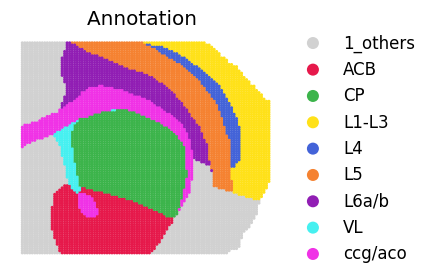

In [4]:
# GT annotation

adata_new = adata1.copy()
adata_new.obs["LayerName"]=adata_new.obs["LayerName"].astype('category')


matplotlib.rcParams['font.size'] = 12.0
fig, axes = plt.subplots(1, 1, figsize=(3.5,3))
sz = 20
plot_color=['#D1D1D1','#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', \
            '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#ffd8b1', '#800000', '#aaffc3', '#808000', '#000075', '#000000', '#808080', '#ffffff', '#fffac8']

domains="LayerName"
num_celltype=len(adata_new.obs[domains].unique())
adata_new.uns[domains+"_colors"]=list(plot_color[:num_celltype])
titles = 'Annotation ' 
ax=sc.pl.scatter(adata_new,alpha=1,x="x_pos",y="y_pos",color=domains,title=titles ,color_map=plot_color,show=False,size=sz,ax = axes)
ax.axis('off')

In [5]:
adata1_feat = preprocess(adata1, modality='rna', save_path='rna_processed.h5ad')
adata2_feat = preprocess(adata2, modality='atac', n_dim=50, save_path='atac_processed.h5ad')

adata1 = sc.read('rna_processed.h5ad')
adata1_feat = adata1.X.toarray() if scipy.sparse.issparse(adata1.X) else adata1.X

adata2 = sc.read('atac_processed.h5ad')
adata2_feat = adata2.obsm['X_lsi'][:, :50]

/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:387: RuntimeWarning: invalid value encountered in log1p
  np.log1p(X, out=X)
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/preprocessing/_scale.py:317: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


✅ Processed RNA data saved to rna_processed.h5ad
⚠️ X_lsi not found, performing LSI in Python from count matrix.
✅ Recomputed and saved ATAC/histone data with new LSI to atac_processed.h5ad


In [6]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="anndata")

features_dict = {
        'rna':  adata1_feat,       
        'atac': adata2_feat     
    }

# setting initial_weights(optional)
initial_weights = [1.0, 1.0]  # matching with the number of modalities

cfg = GSMOConfig
# cfg = GSMOConfig.presets("v1")
            
model = GSMO(features_dict, spatial_coords=spatial_coords, device=device, cfg=cfg, trainable_weights=True, initial_weights=initial_weights)

/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [7]:
labels = pd.factorize(adata1.obs['LayerName'])[0]

model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

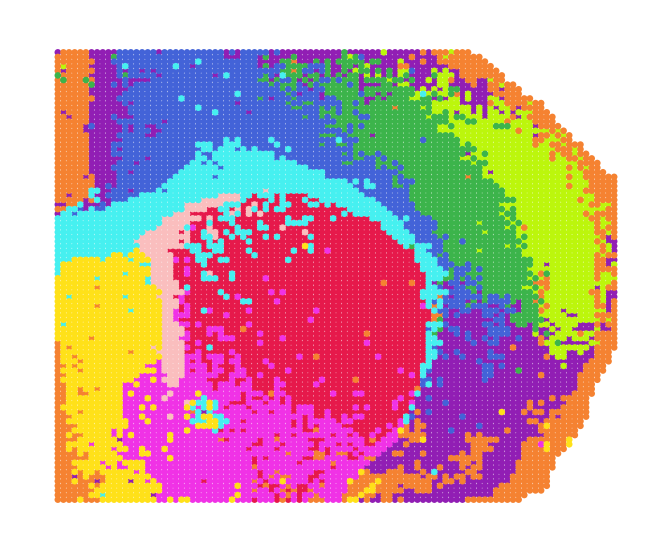

In [10]:
#clustering

from matplotlib.colors import ListedColormap


rna_locs = adata1.obsm['spatial'] 
assert rna_locs is not None and rna_locs.shape[1] == 2, "The RNA data is missing position information or the format is incorrect. Please check the data."

# clustering results
clusters = model.cluster_kmeans(n_clusters=10)

rna_locs_df = pd.DataFrame(rna_locs, columns=['x', 'y'])  
rna_locs_df['cluster'] = clusters  


adata_new = adata1.copy()

df_embedding = model.get_embeddings()
embedding_adata = sc.AnnData(df_embedding)
sc.pp.neighbors(embedding_adata, n_neighbors=50, use_rep='X')

adata_new.obs['GSMO'] = list(clusters)
adata_new.obs["GSMO"] = adata_new.obs["GSMO"].astype('category')

digit_labels = list(adata_new.obs['GSMO'])
for i in range(len(digit_labels)):
    if digit_labels[i] not in list(range(10)):
        digit_labels[i] = 100
adata_new.obs['GSMO'] = digit_labels
adata_new.obs["GSMO"] = adata_new.obs["GSMO"].astype('category')

plot_color = ['#e6194b', '#911eb4', '#bcf60c', '#f58231', '#f032e6',
                '#3cb44b', '#fabebe', '#4363d8', '#46f0f0', '#ffe119',
                '#D1D1D1']  


domains = "GSMO"
num_celltype = len(adata_new.obs[domains].unique())
adata_new.uns[domains + "_colors"] = list(plot_color[:num_celltype])

x_range = adata_new.obs["x_pos"].max() - adata_new.obs["x_pos"].min()
y_range = adata_new.obs["y_pos"].max() - adata_new.obs["y_pos"].min()
aspect_ratio = x_range / y_range

base_height = 2
fig_width = base_height * 1.2# aspect_ratio

matplotlib.rcParams['figure.dpi'] = 300

# visualization
fig, ax = plt.subplots(figsize=(fig_width, base_height))
sc.pl.scatter(
    adata_new,
    alpha=1,
    x="x_pos",
    y="y_pos",
    color=domains,
    show=False,
    size=10,
    ax=ax,
    title="",
    legend_loc='none'
)
ax.axis('off')
plt.tight_layout()
plt.show()

# save picture
# plt.savefig("gsmo_clusters.png", dpi=600, bbox_inches='tight')




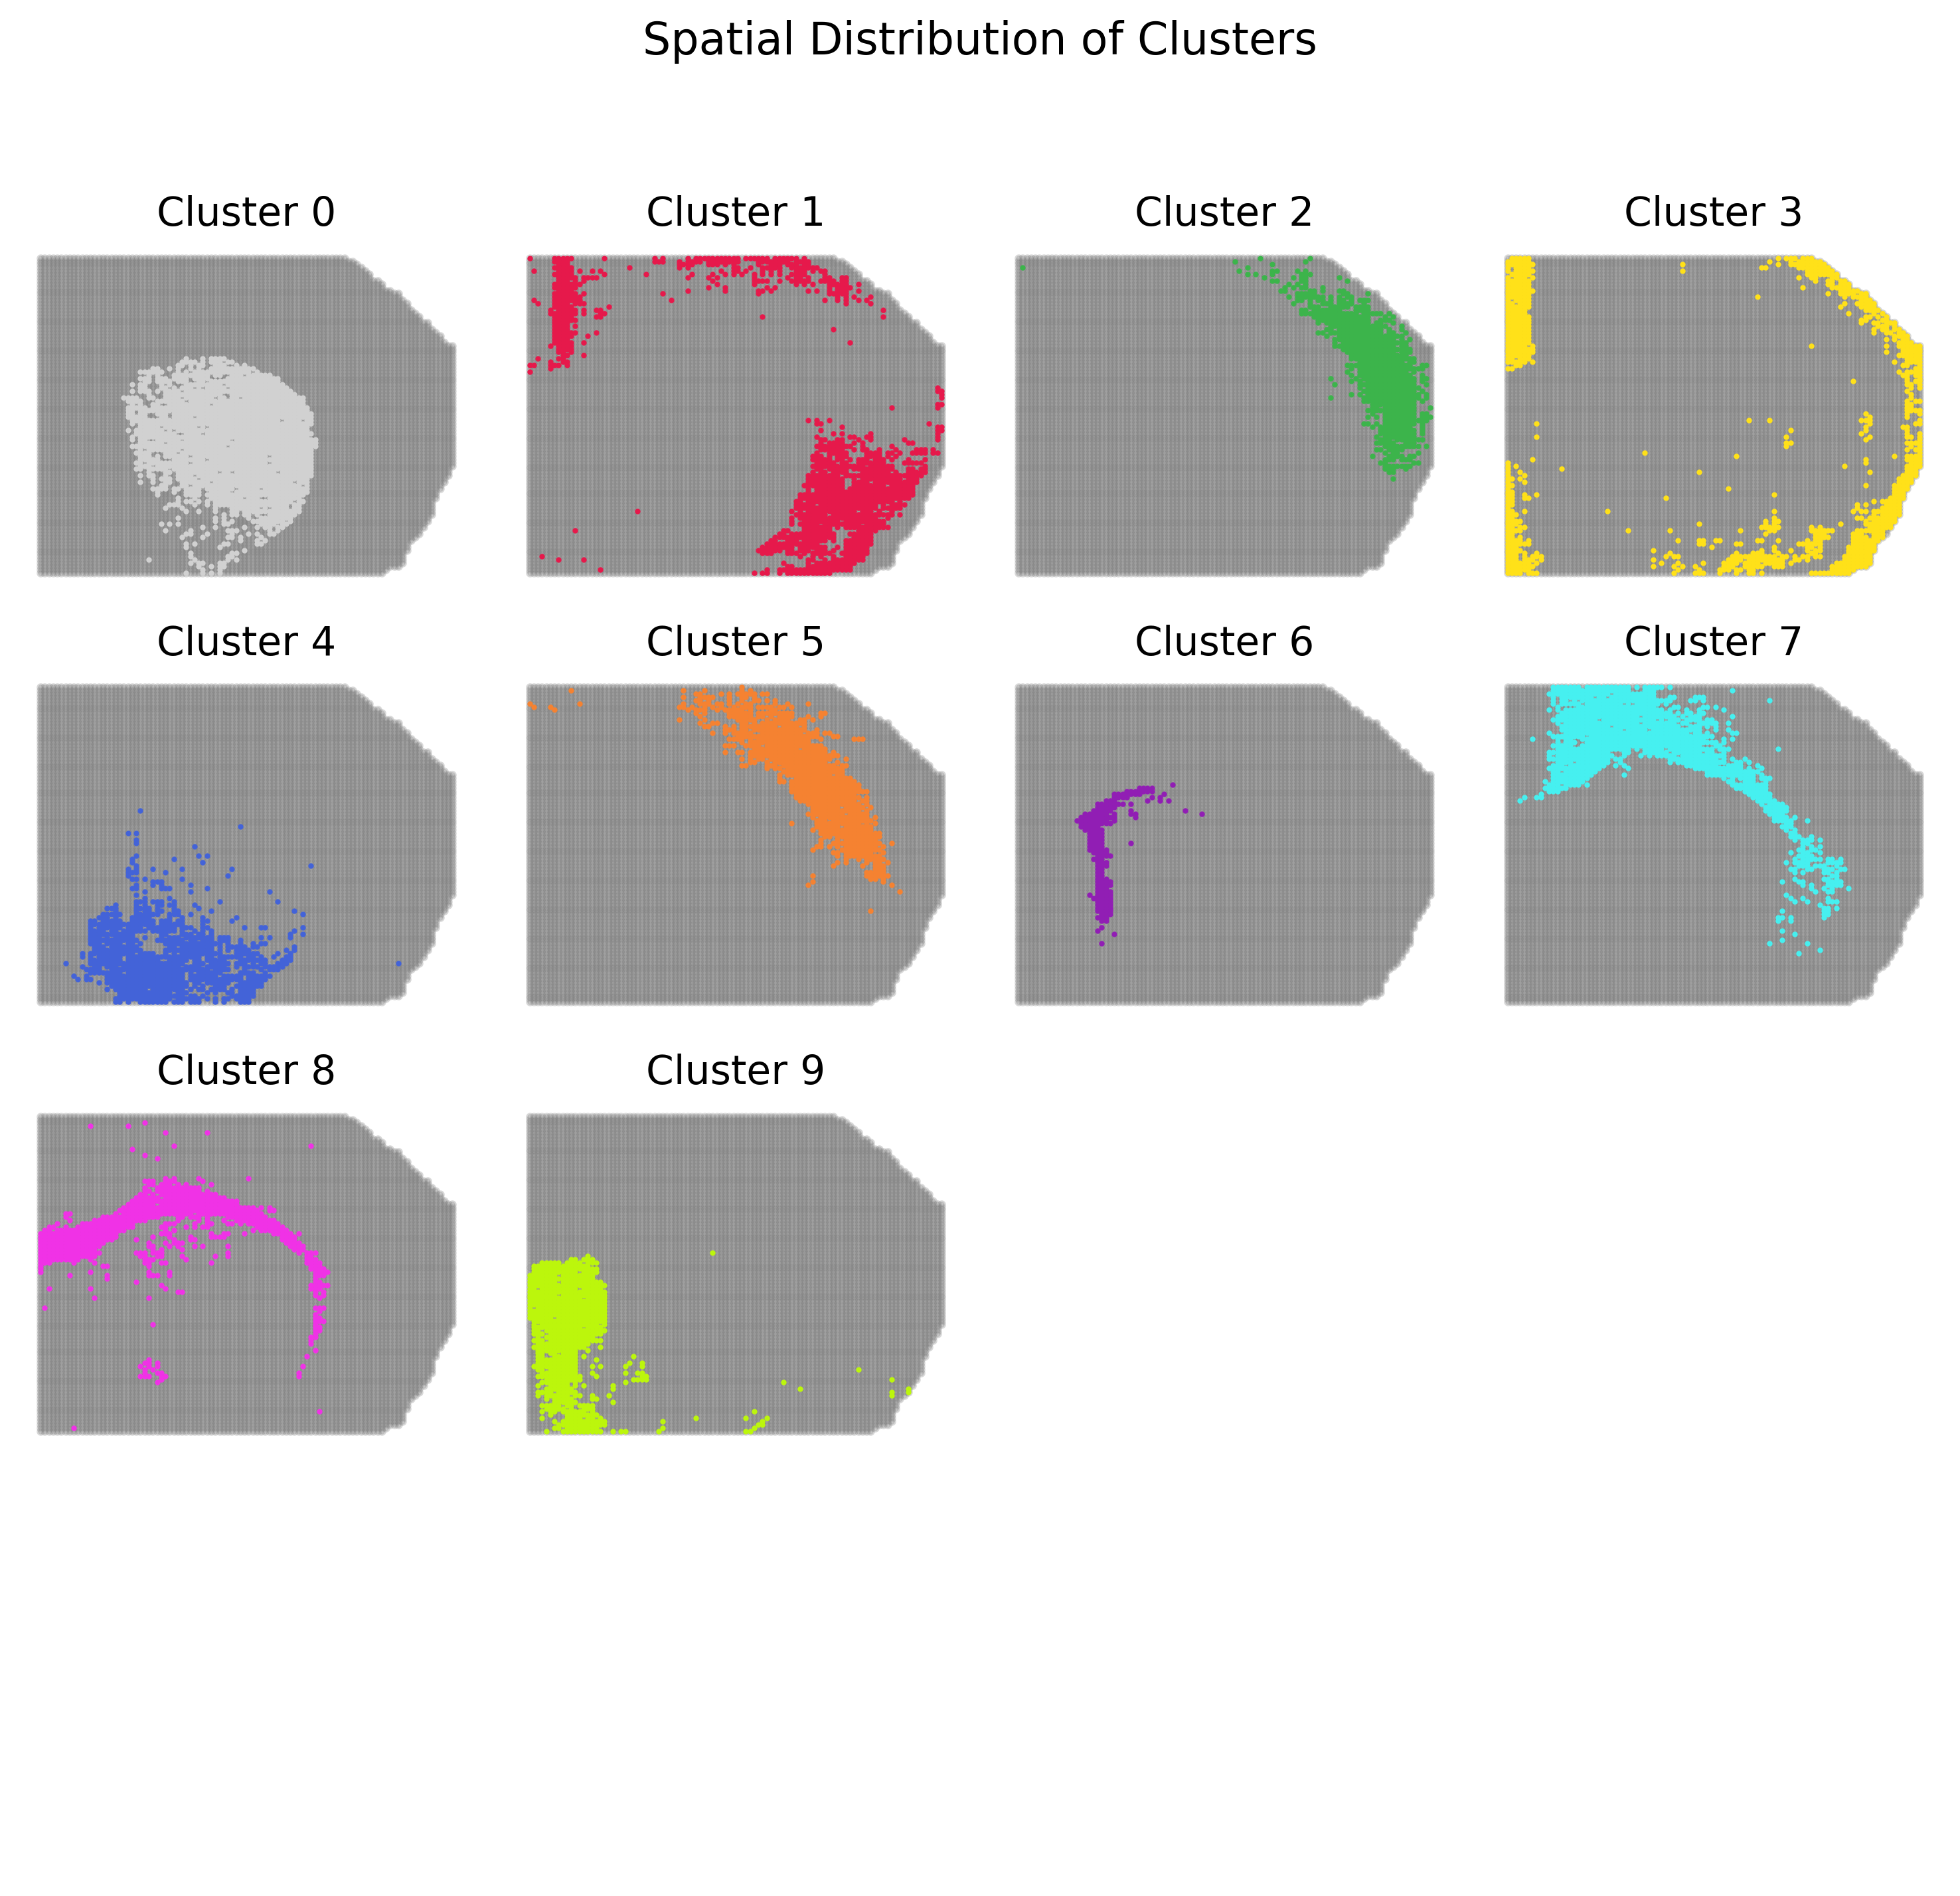

In [17]:
# show each specific cluster
clusters_new = adata_new.obs['GSMO'].cat.categories[:10]  
x = np.array(adata_new.obs['x_pos'])
y = np.array(adata_new.obs['y_pos'])

num_clusters = len(clusters_new)
grid_size = int(np.ceil(np.sqrt(num_clusters)))  

fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
axes = axes.flatten() 


for idx, cluster in enumerate(clusters_new):

    cluster_cells = adata_new.obs['GSMO'] == cluster

    all_x = x
    all_y = y
    
    cluster_x = x[cluster_cells]
    cluster_y = y[cluster_cells]
    
    ax = axes[idx]
    ax.scatter(all_x, all_y, s=4, color='gray', alpha=0.3) 

    cluster_color = plot_color[cluster] 
    ax.scatter(cluster_x, cluster_y, s=1, color=cluster_color, alpha=1)

    ax.set_title(f'Cluster {cluster}')
    ax.axis('off')  

for idx in range(num_clusters, len(axes)):
    ax = axes[idx]
    ax.axis('off') 


plt.suptitle("Spatial Distribution of Clusters", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  

plt.show()


In [9]:
# evaluate clustering results using six supervised metrics

from sklearn.metrics import (
    adjusted_rand_score,
    homogeneity_score,
    mutual_info_score,
    v_measure_score,
    adjusted_mutual_info_score,
    normalized_mutual_info_score,
)

def evaluate_clustering_metrics():

    LayerName = list(data_mat['LayerName'])
    LayerName = [item.decode("utf-8") for item in LayerName]
    true_labels = LayerName
    cluster_labels = clusters

    scores = {
        "ARI": adjusted_rand_score(true_labels, cluster_labels),
        "Homogeneity": homogeneity_score(true_labels, cluster_labels),
        "Mutual Info": mutual_info_score(true_labels, cluster_labels),
        "V-measure": v_measure_score(true_labels, cluster_labels),
        "AMI": adjusted_mutual_info_score(true_labels, cluster_labels),
        "NMI": normalized_mutual_info_score(true_labels, cluster_labels),
    }

    print("=== Clustering Evaluation Metrics ===")
    for k, v in scores.items():
        print(f"{k}: {v:.4f}")
    
    return scores


scores = evaluate_clustering_metrics()


=== Clustering Evaluation Metrics ===
ARI: 0.2427
Homogeneity: 0.4131
Mutual Info: 0.8254
V-measure: 0.3867
AMI: 0.3855
NMI: 0.3867


In [10]:
# evaluate using two unsupervised metrics
from sklearn.metrics import pairwise_distances
from tqdm import tqdm

def compute_jaccard_similarity(Z_m, Z_e, k=50):
    dist_m = pairwise_distances(Z_m)
    dist_e = pairwise_distances(Z_e)
    
    n = Z_m.shape[0]
    jaccard_scores = []

    for i in tqdm(range(n), desc="Calculating Jaccard similarities"):
        neighbors_m = set(np.argsort(dist_m[i])[1:k+1])  # exclude self
        neighbors_e = set(np.argsort(dist_e[i])[1:k+1])
        intersection = len(neighbors_m & neighbors_e)
        union = len(neighbors_m | neighbors_e)
        jaccard = intersection / union if union > 0 else 0.0
        jaccard_scores.append(jaccard)

    return np.array(jaccard_scores), np.mean(jaccard_scores)


import squidpy as sq


def compute_morans_I(labels, spatial_coords, label_name="cluster_label"):

    adata = sc.AnnData(X=np.zeros((len(labels), 1))) 
    adata.obs[label_name] = pd.Categorical([str(x) for x in labels])
    adata.obsm['spatial'] = spatial_coords.astype(float)

    sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=6)

    sq.gr.spatial_autocorr(adata, mode="moran", genes=label_name, attr="obs")

    moran_result = adata.uns["moranI"].loc[label_name, "I"]
    return moran_result
fused_embeddings = model.get_embeddings()


# Jaccard
jaccard_all, jaccard_mean = compute_jaccard_similarity(adata1.X, fused_embeddings, k=50)
print(f"Mean Jaccard RNA Similarity: {jaccard_mean:.4f}")

jaccard_all, jaccard_mean = compute_jaccard_similarity(adata2.X, fused_embeddings, k=50)
print(f"Mean Jaccard ATAC Similarity: {jaccard_mean:.4f}")


# Moran's I score (global)
cluster_labels = adata_new.obs['GSMO'].cat.codes
morans_I = compute_morans_I(cluster_labels, spatial_coords)
print(f"Moran's I score: {morans_I:.4f}")



/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
Calculating Jaccard similarities: 100%|██████████| 9215/9215 [00:06<00:00, 1486.43it/s]


Mean Jaccard RNA Similarity: 0.0108


Calculating Jaccard similarities: 100%|██████████| 9215/9215 [00:05<00:00, 1603.72it/s]


Mean Jaccard ATAC Similarity: 0.0694
Moran's I score: 0.5228


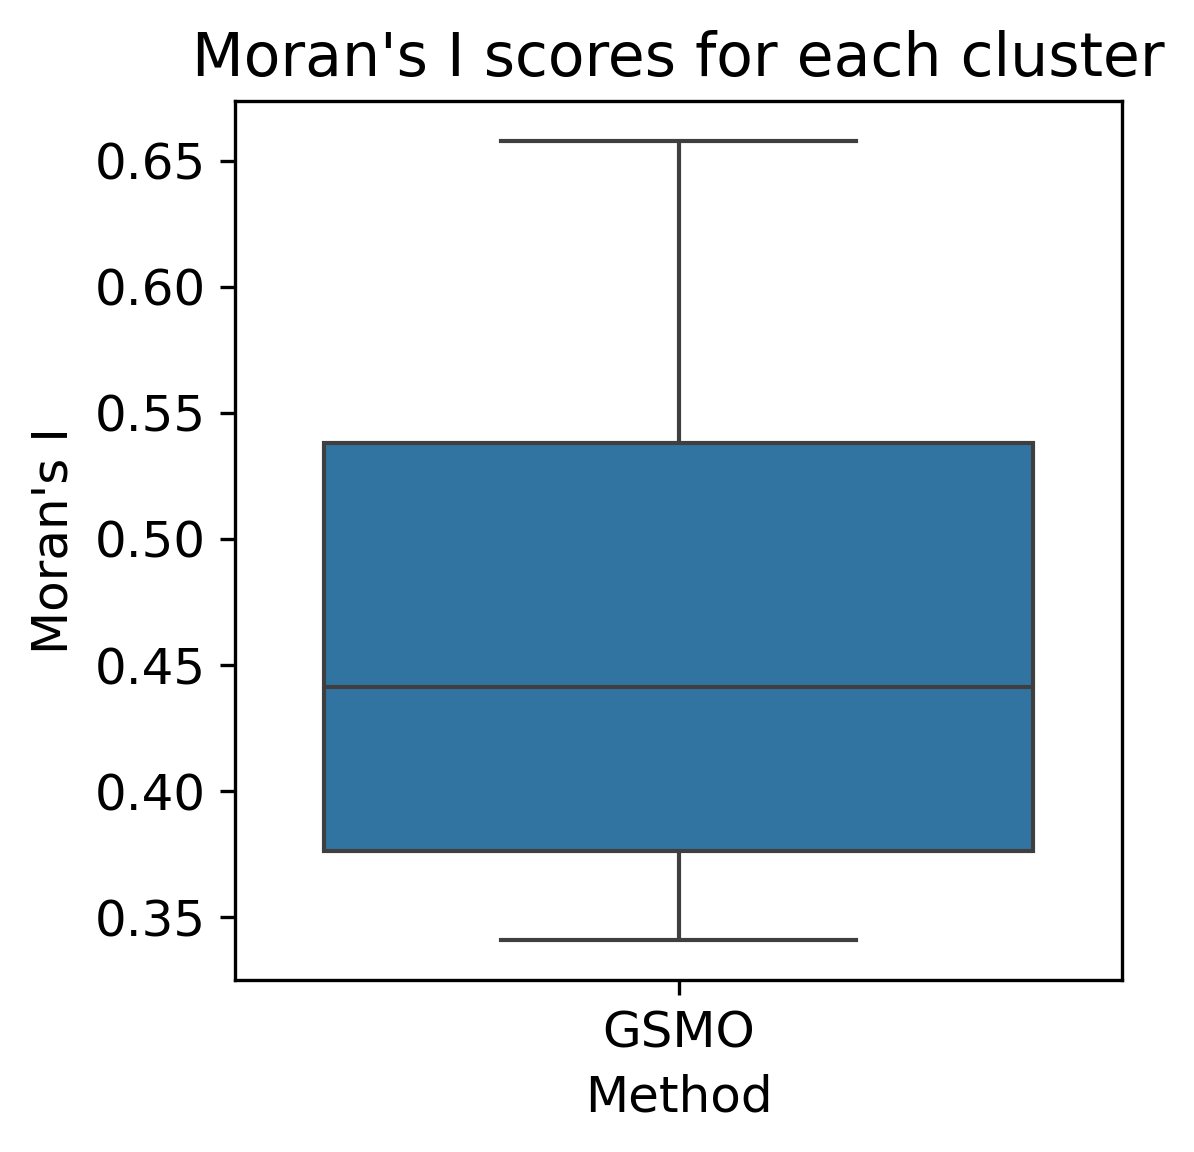

  cluster   moran_I method
0       0  0.348201   GSMO
1       1  0.461943   GSMO
2       2  0.503636   GSMO
3       3  0.379247   GSMO
4       4  0.420788   GSMO
5       5  0.375321   GSMO
6       6  0.657806   GSMO
7       7  0.340926   GSMO
8       8  0.549667   GSMO
9       9  0.638789   GSMO


: 

In [ ]:
# Moran's I score across clusters
import squidpy as sq
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def compute_morans_I_per_method(labels, spatial_coords, method_name="MethodA"):

    adata = sc.AnnData(X=np.zeros((len(labels), 1)))
    adata.obs["cluster_label"] = pd.Categorical([str(x) for x in labels])
    adata.obsm['spatial'] = spatial_coords.astype(float)

    # Construct spatial adjacency graph
    sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=6)

    moran_scores = []
    unique_labels = np.unique(labels)

    for label in unique_labels:
        binary_vector = (labels == label).astype(int)
        adata.obs["tmp_binary"] = binary_vector

        sq.gr.spatial_autocorr(adata, mode="moran", genes="tmp_binary", attr="obs")
        I_score = adata.uns["moranI"].loc["tmp_binary", "I"]
        moran_scores.append({
            "cluster": str(label),
            "moran_I": I_score,
            "method": method_name
        })

    df_moran = pd.DataFrame(moran_scores)

    plt.figure(figsize=(4, 4))
    sns.boxplot(data=df_moran, x="method", y="moran_I")
    plt.title("Moran's I scores for each cluster")
    plt.ylabel("Moran's I")
    plt.xlabel("Method")
    plt.tight_layout()
    plt.show()

    return df_moran

morans_I_df = compute_morans_I_per_method(cluster_labels, spatial_coords, method_name="GSMO")
print(morans_I_df)


/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldc

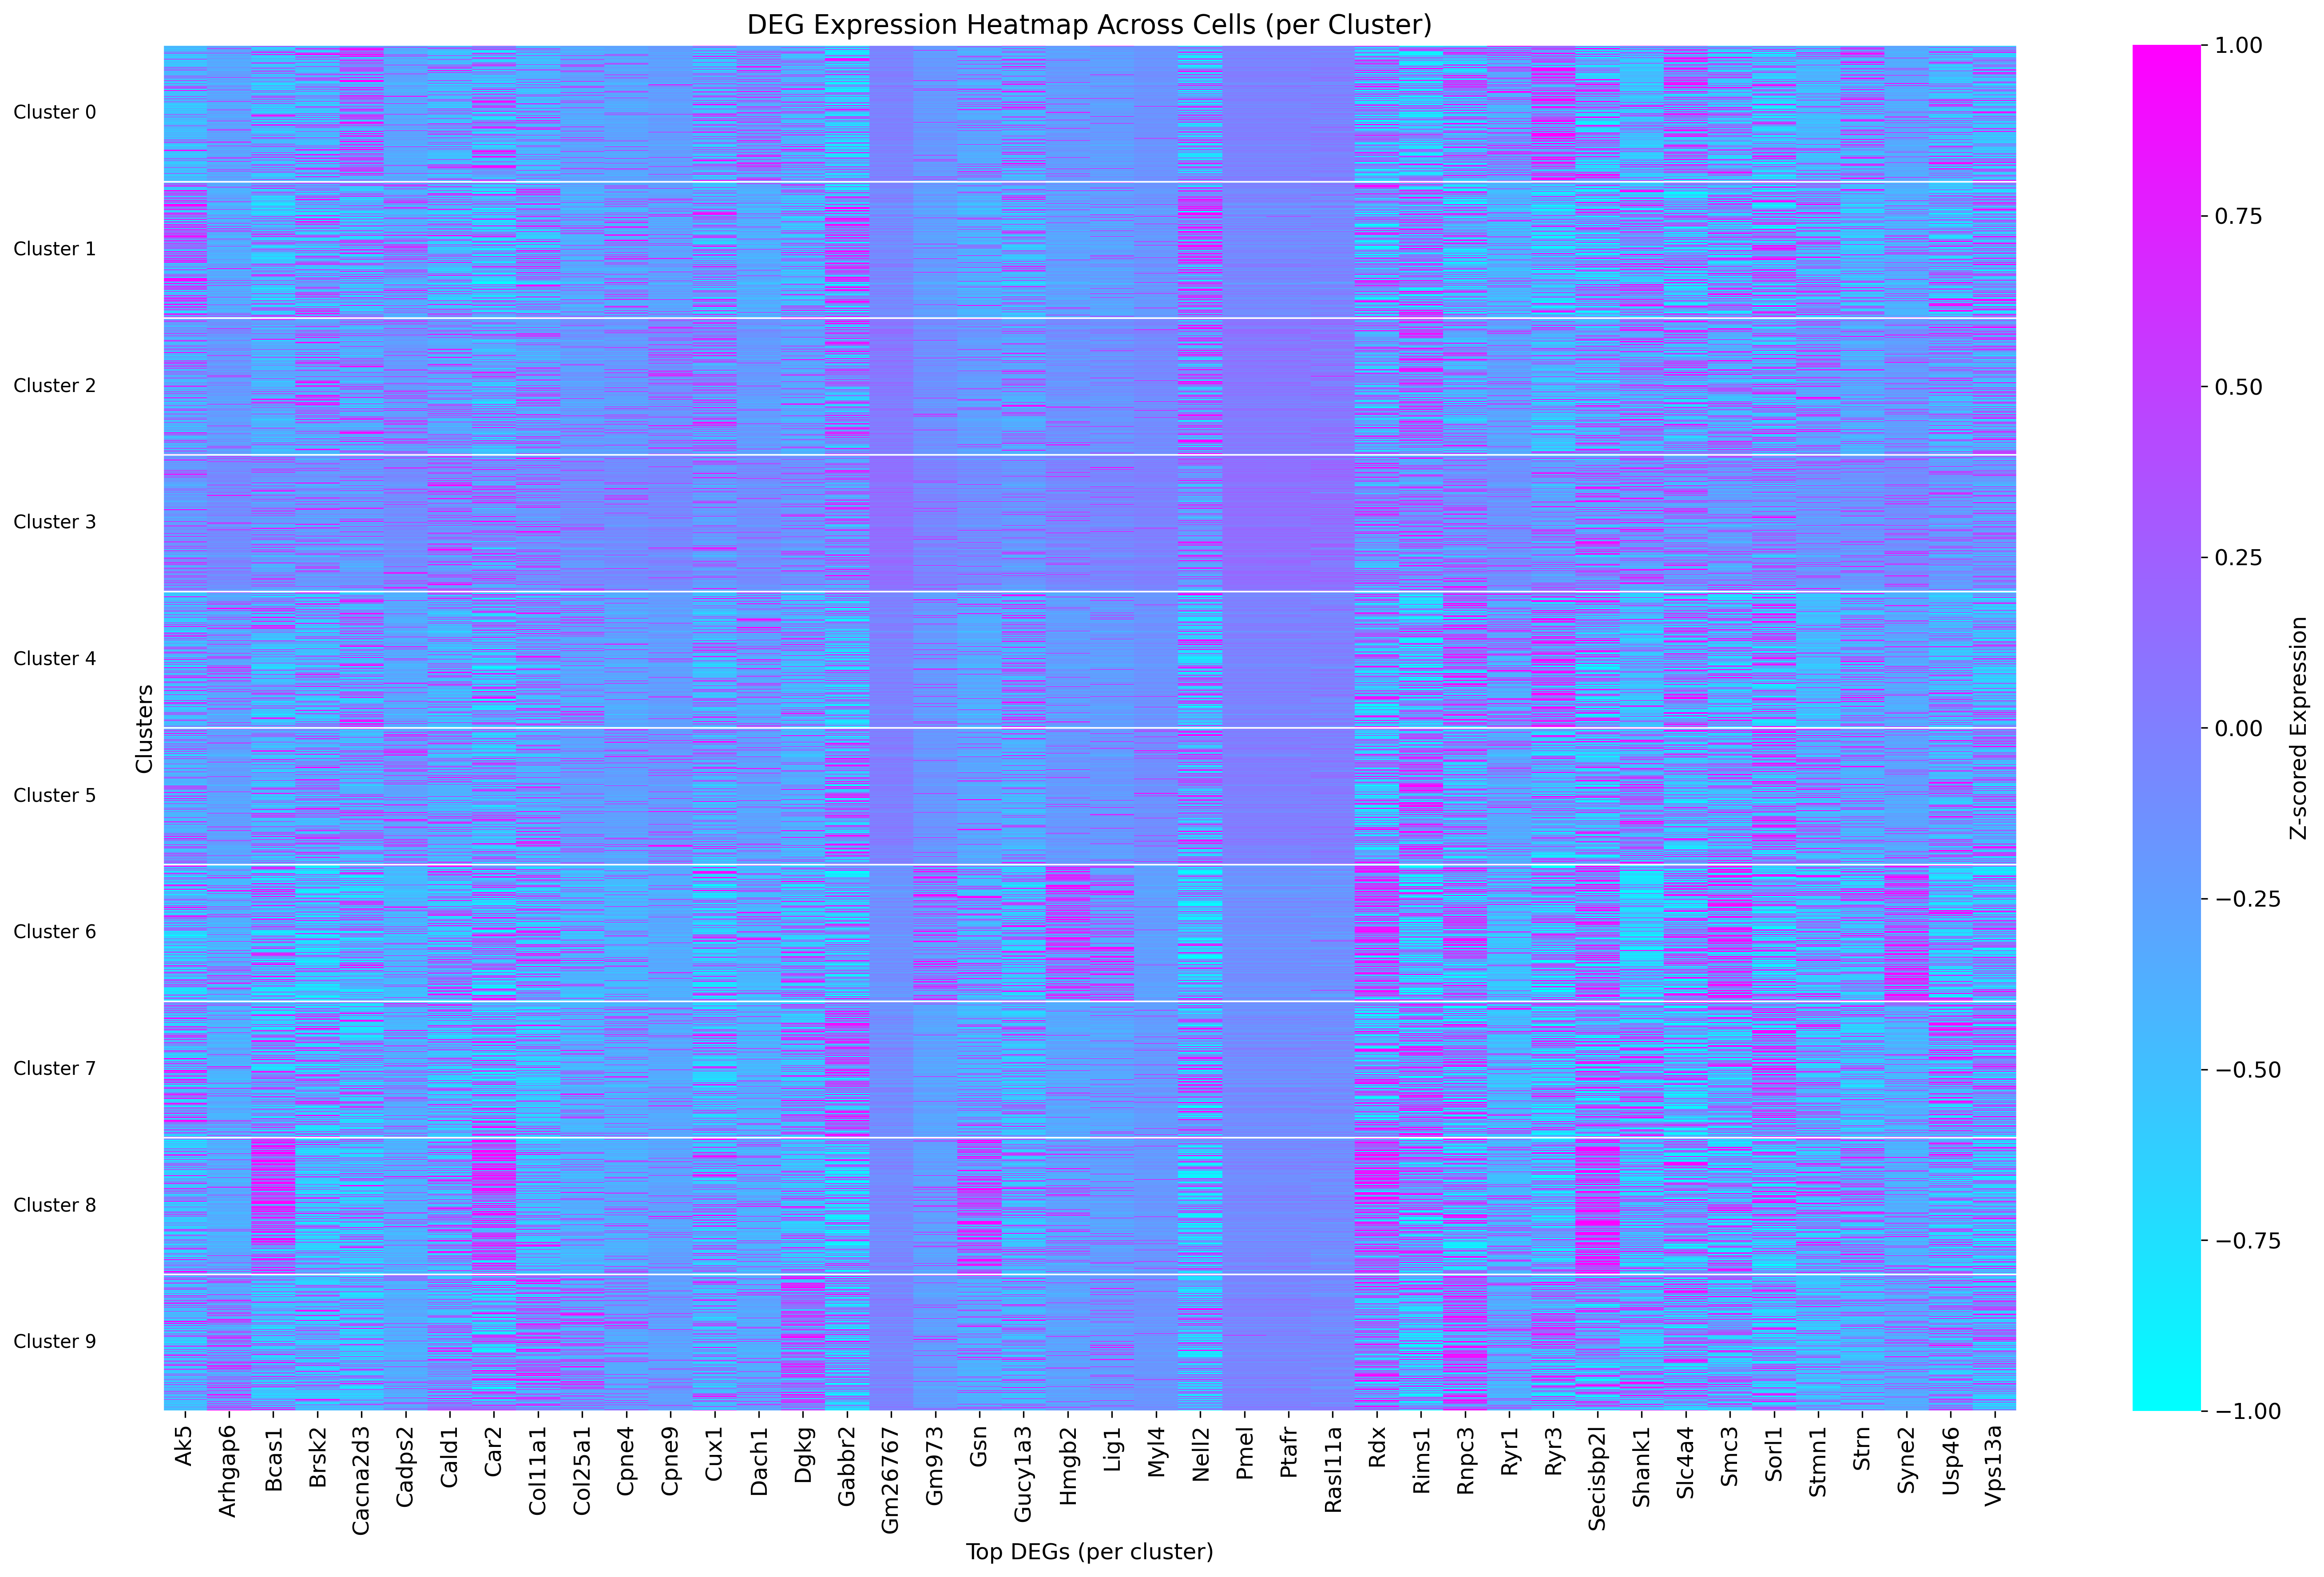

In [33]:
# heat map of cell-level DEG

import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle

sc.tl.rank_genes_groups(adata_new, groupby='GSMO', method='t-test', n_genes=50)
deg_results = adata_new.uns['rank_genes_groups']
deg_df = pd.DataFrame(deg_results['names']).T
top_genes = np.unique(deg_df.iloc[:, :5].values.flatten())

adata_sub = adata_new[:, top_genes].copy()
sc.pp.scale(adata_sub, zero_center=True)
expr = adata_sub.X.toarray() if not isinstance(adata_sub.X, np.ndarray) else adata_sub.X
expr = np.clip(expr, -1, 1)
expr_df = pd.DataFrame(expr, columns=top_genes, index=adata_sub.obs_names)
expr_df['cluster'] = adata_sub.obs['GSMO'].values

n_cells_per_cluster = 800
clustered_dfs = []

for cluster in sorted(expr_df['cluster'].unique()):
    cluster_df = expr_df[expr_df['cluster'] == cluster].drop(columns='cluster')
    if len(cluster_df) >= n_cells_per_cluster:
        sampled = cluster_df.sample(n=n_cells_per_cluster, random_state=0)
    else:
        sampled = cluster_df.sample(n=n_cells_per_cluster, replace=True, random_state=0)
    sampled['cluster'] = cluster
    clustered_dfs.append(sampled)

uniform_df = pd.concat(clustered_dfs)
uniform_df_sorted = uniform_df.sort_values(by='cluster')
uniform_df_clean = uniform_df_sorted.drop(columns='cluster')

cluster_labels = uniform_df_sorted['cluster'].values
unique_clusters = sorted(np.unique(cluster_labels))

fig, ax = plt.subplots(figsize=(len(top_genes) * 0.4 + 2, 12))  
sns.heatmap(uniform_df_clean, cmap='cool', annot=False, yticklabels=False,
            cbar_kws={'label': 'Z-scored Expression'}, linewidths=0, ax=ax)

cluster_start = 0
for cluster in unique_clusters:
    ax.add_patch(Rectangle((0, cluster_start), len(top_genes), n_cells_per_cluster,
                           linewidth=0.8, edgecolor='white', facecolor='none'))

    y_center = cluster_start + n_cells_per_cluster / 2
    ax.text(-1.5, y_center, f'Cluster {cluster}', va='center', ha='right', fontsize=10, rotation=0)
    
    cluster_start += n_cells_per_cluster

plt.title("DEG Expression Heatmap Across Cells (per Cluster)")
plt.xlabel("Top DEGs (per cluster)")
plt.ylabel("Clusters")
plt.tight_layout()

# plt.savefig("/opt/user2/1/gsmo/data/cosmos/DEG_cell_level_heatmap_with_labels_cool.png", dpi=600, bbox_inches='tight')
plt.show()


/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldc

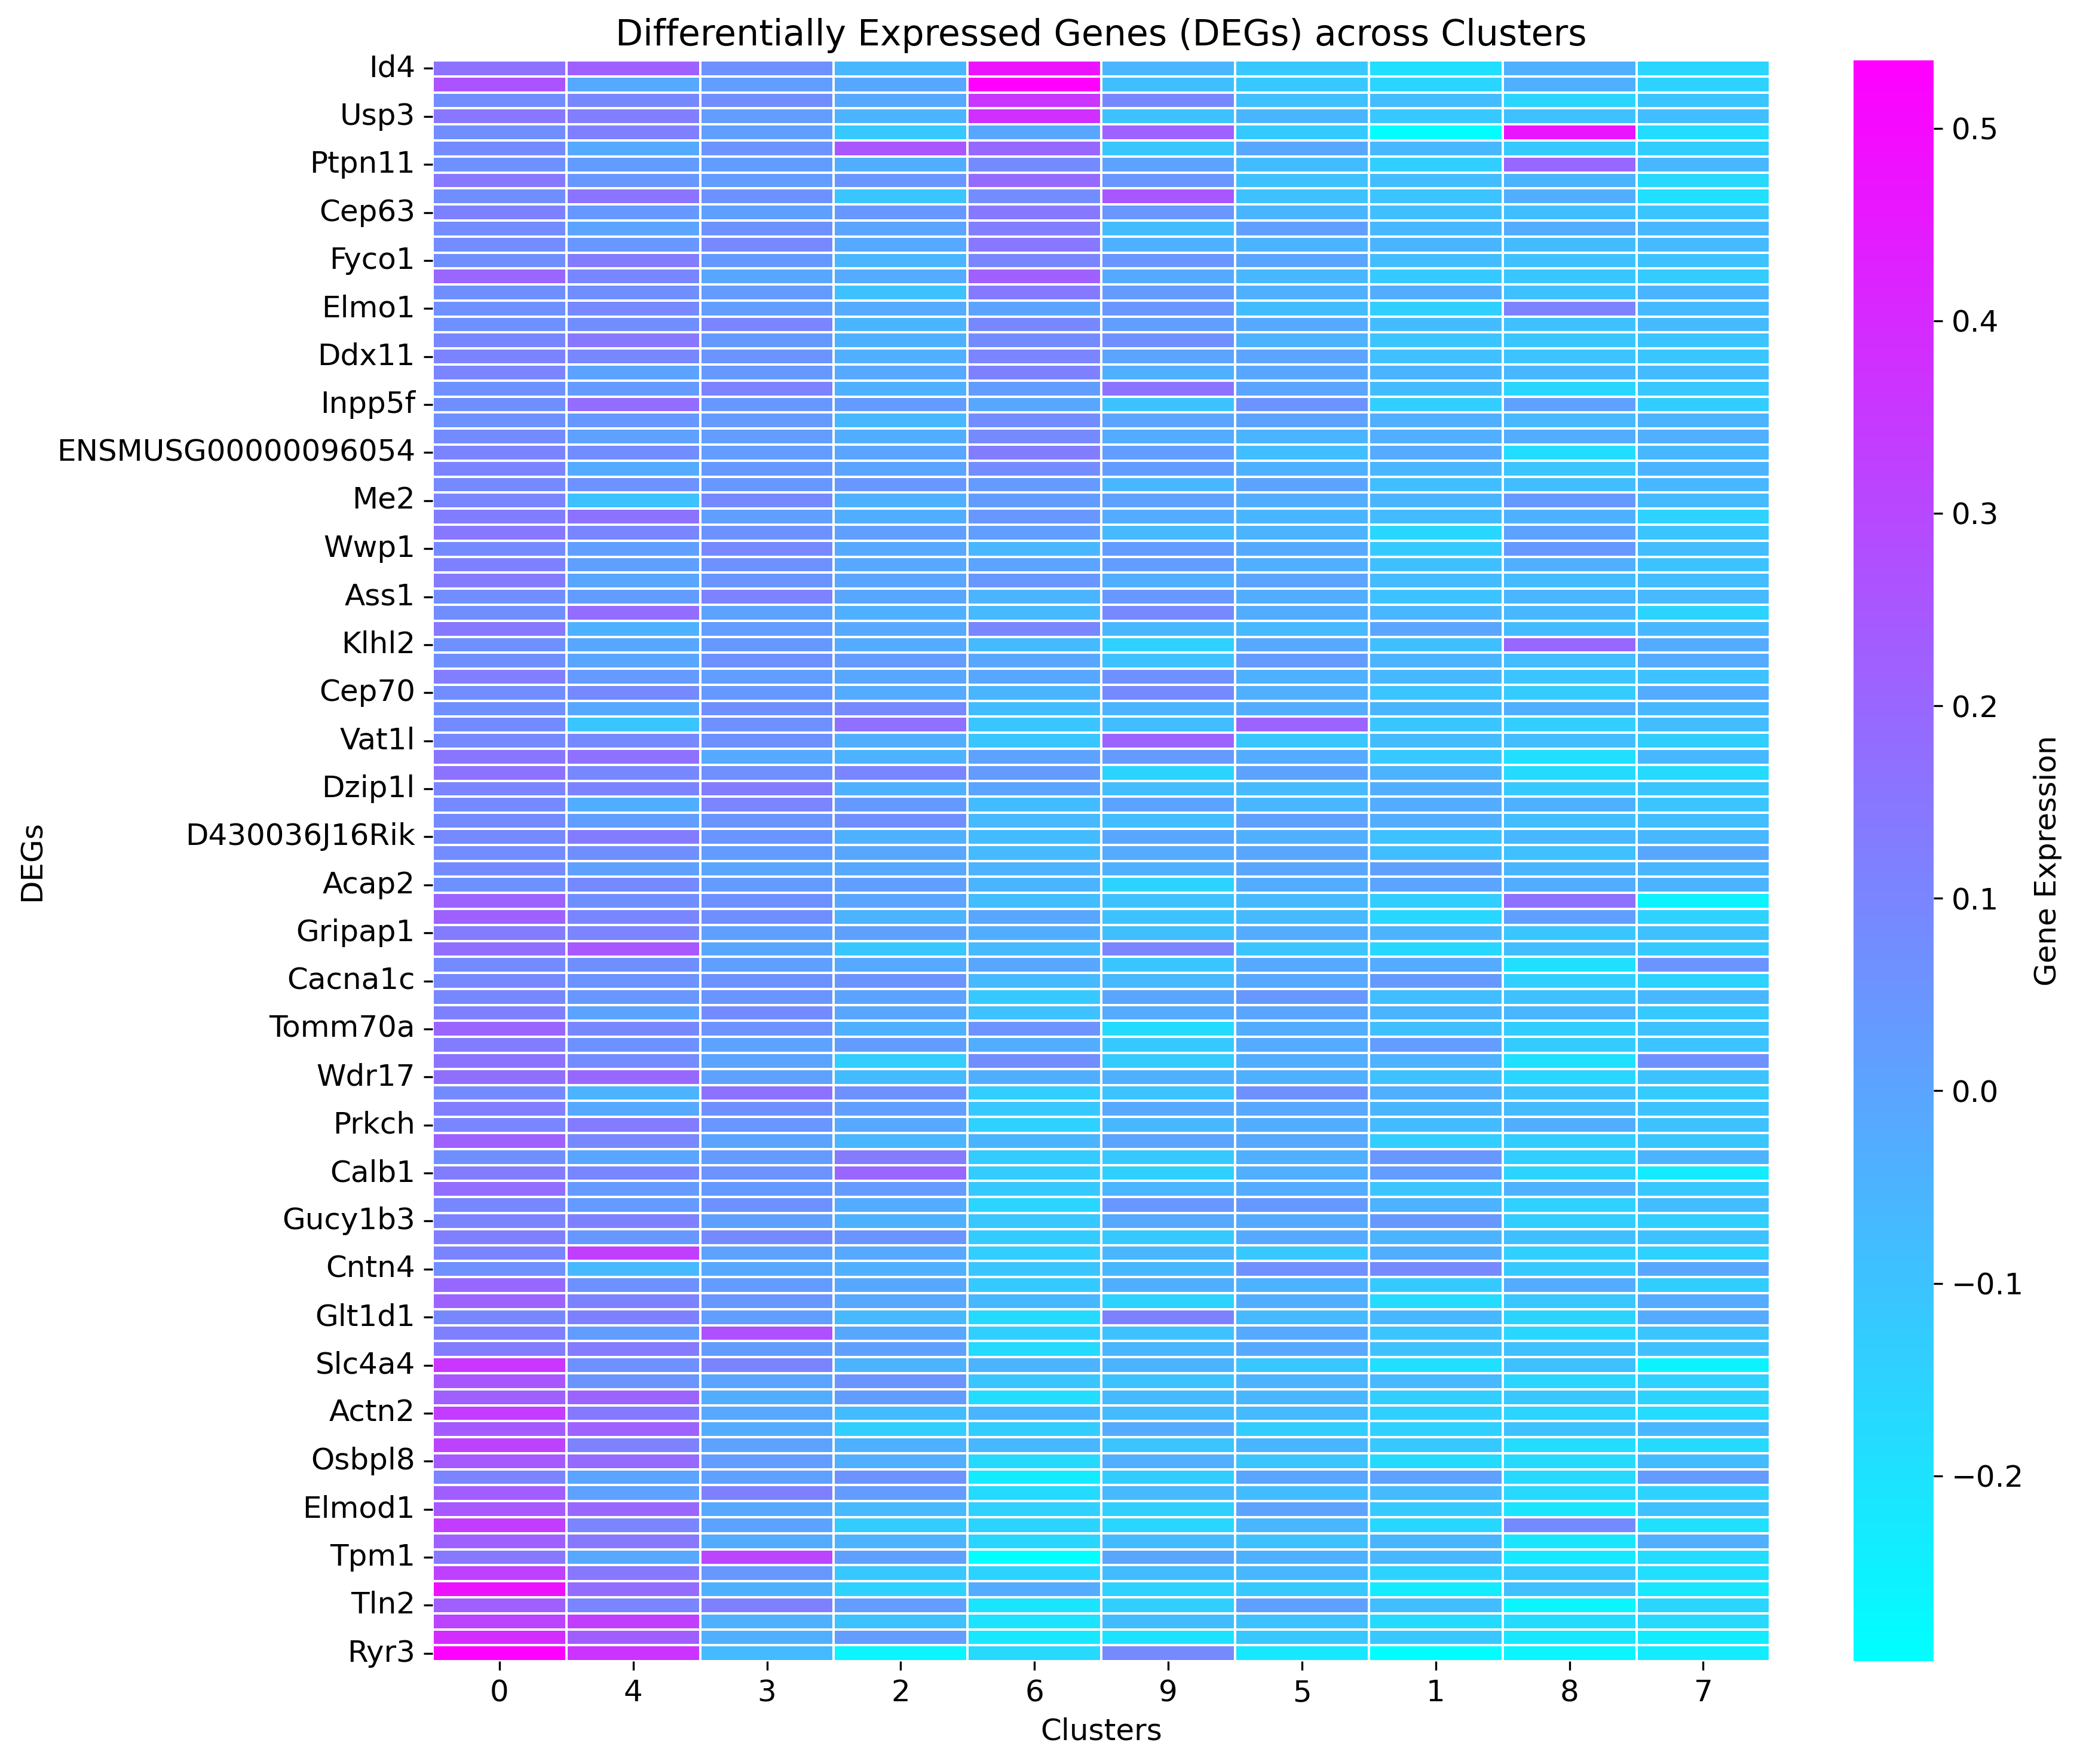

In [24]:
# Heat Map of Differentially Expressed Genes (DEGs) across Clusters
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


sc.tl.rank_genes_groups(adata_new, groupby='GSMO', method='t-test', n_genes=100) 

deg_results = adata_new.uns['rank_genes_groups']
deg_df = pd.DataFrame(deg_results['names']).T 

top_genes = deg_df.iloc[0].values 

adata_new.raw = adata_new 
sc.pp.scale(adata_new, zero_center=True) 

deg_gene_expression = []

for gene in top_genes:
    gene_expression = []
    for cluster in np.unique(adata_new.obs['GSMO']):
        cluster_cells = adata_new[adata_new.obs['GSMO'] == cluster]
        gene_expression.append(cluster_cells[:, gene].X.toarray().mean())
    deg_gene_expression.append(gene_expression)

deg_gene_expression = np.array(deg_gene_expression)
deg_expression_df = pd.DataFrame(deg_gene_expression, columns=np.unique(adata_new.obs['GSMO']), index=top_genes)

# sort genes
gene_order = deg_expression_df.mean(axis=1).sort_values(ascending=False).index
deg_expression_df = deg_expression_df.loc[gene_order, :]

# sort clusters
cluster_order = deg_expression_df.mean(axis=0).sort_values(ascending=False).index
deg_expression_df = deg_expression_df.loc[:, cluster_order]

plt.figure(figsize=(12, 10))  
sns.heatmap(deg_expression_df, cmap='cool', annot=False, fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Gene Expression'})
plt.title("Differentially Expressed Genes (DEGs) across Clusters")
plt.xlabel("Clusters")
plt.ylabel("DEGs")
plt.tight_layout()


# plt.savefig("/opt/user2/1/gsmo/data/cosmos/DEG_heatmap_sorted.png", dpi=600, bbox_inches='tight')

plt.show()


/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldc

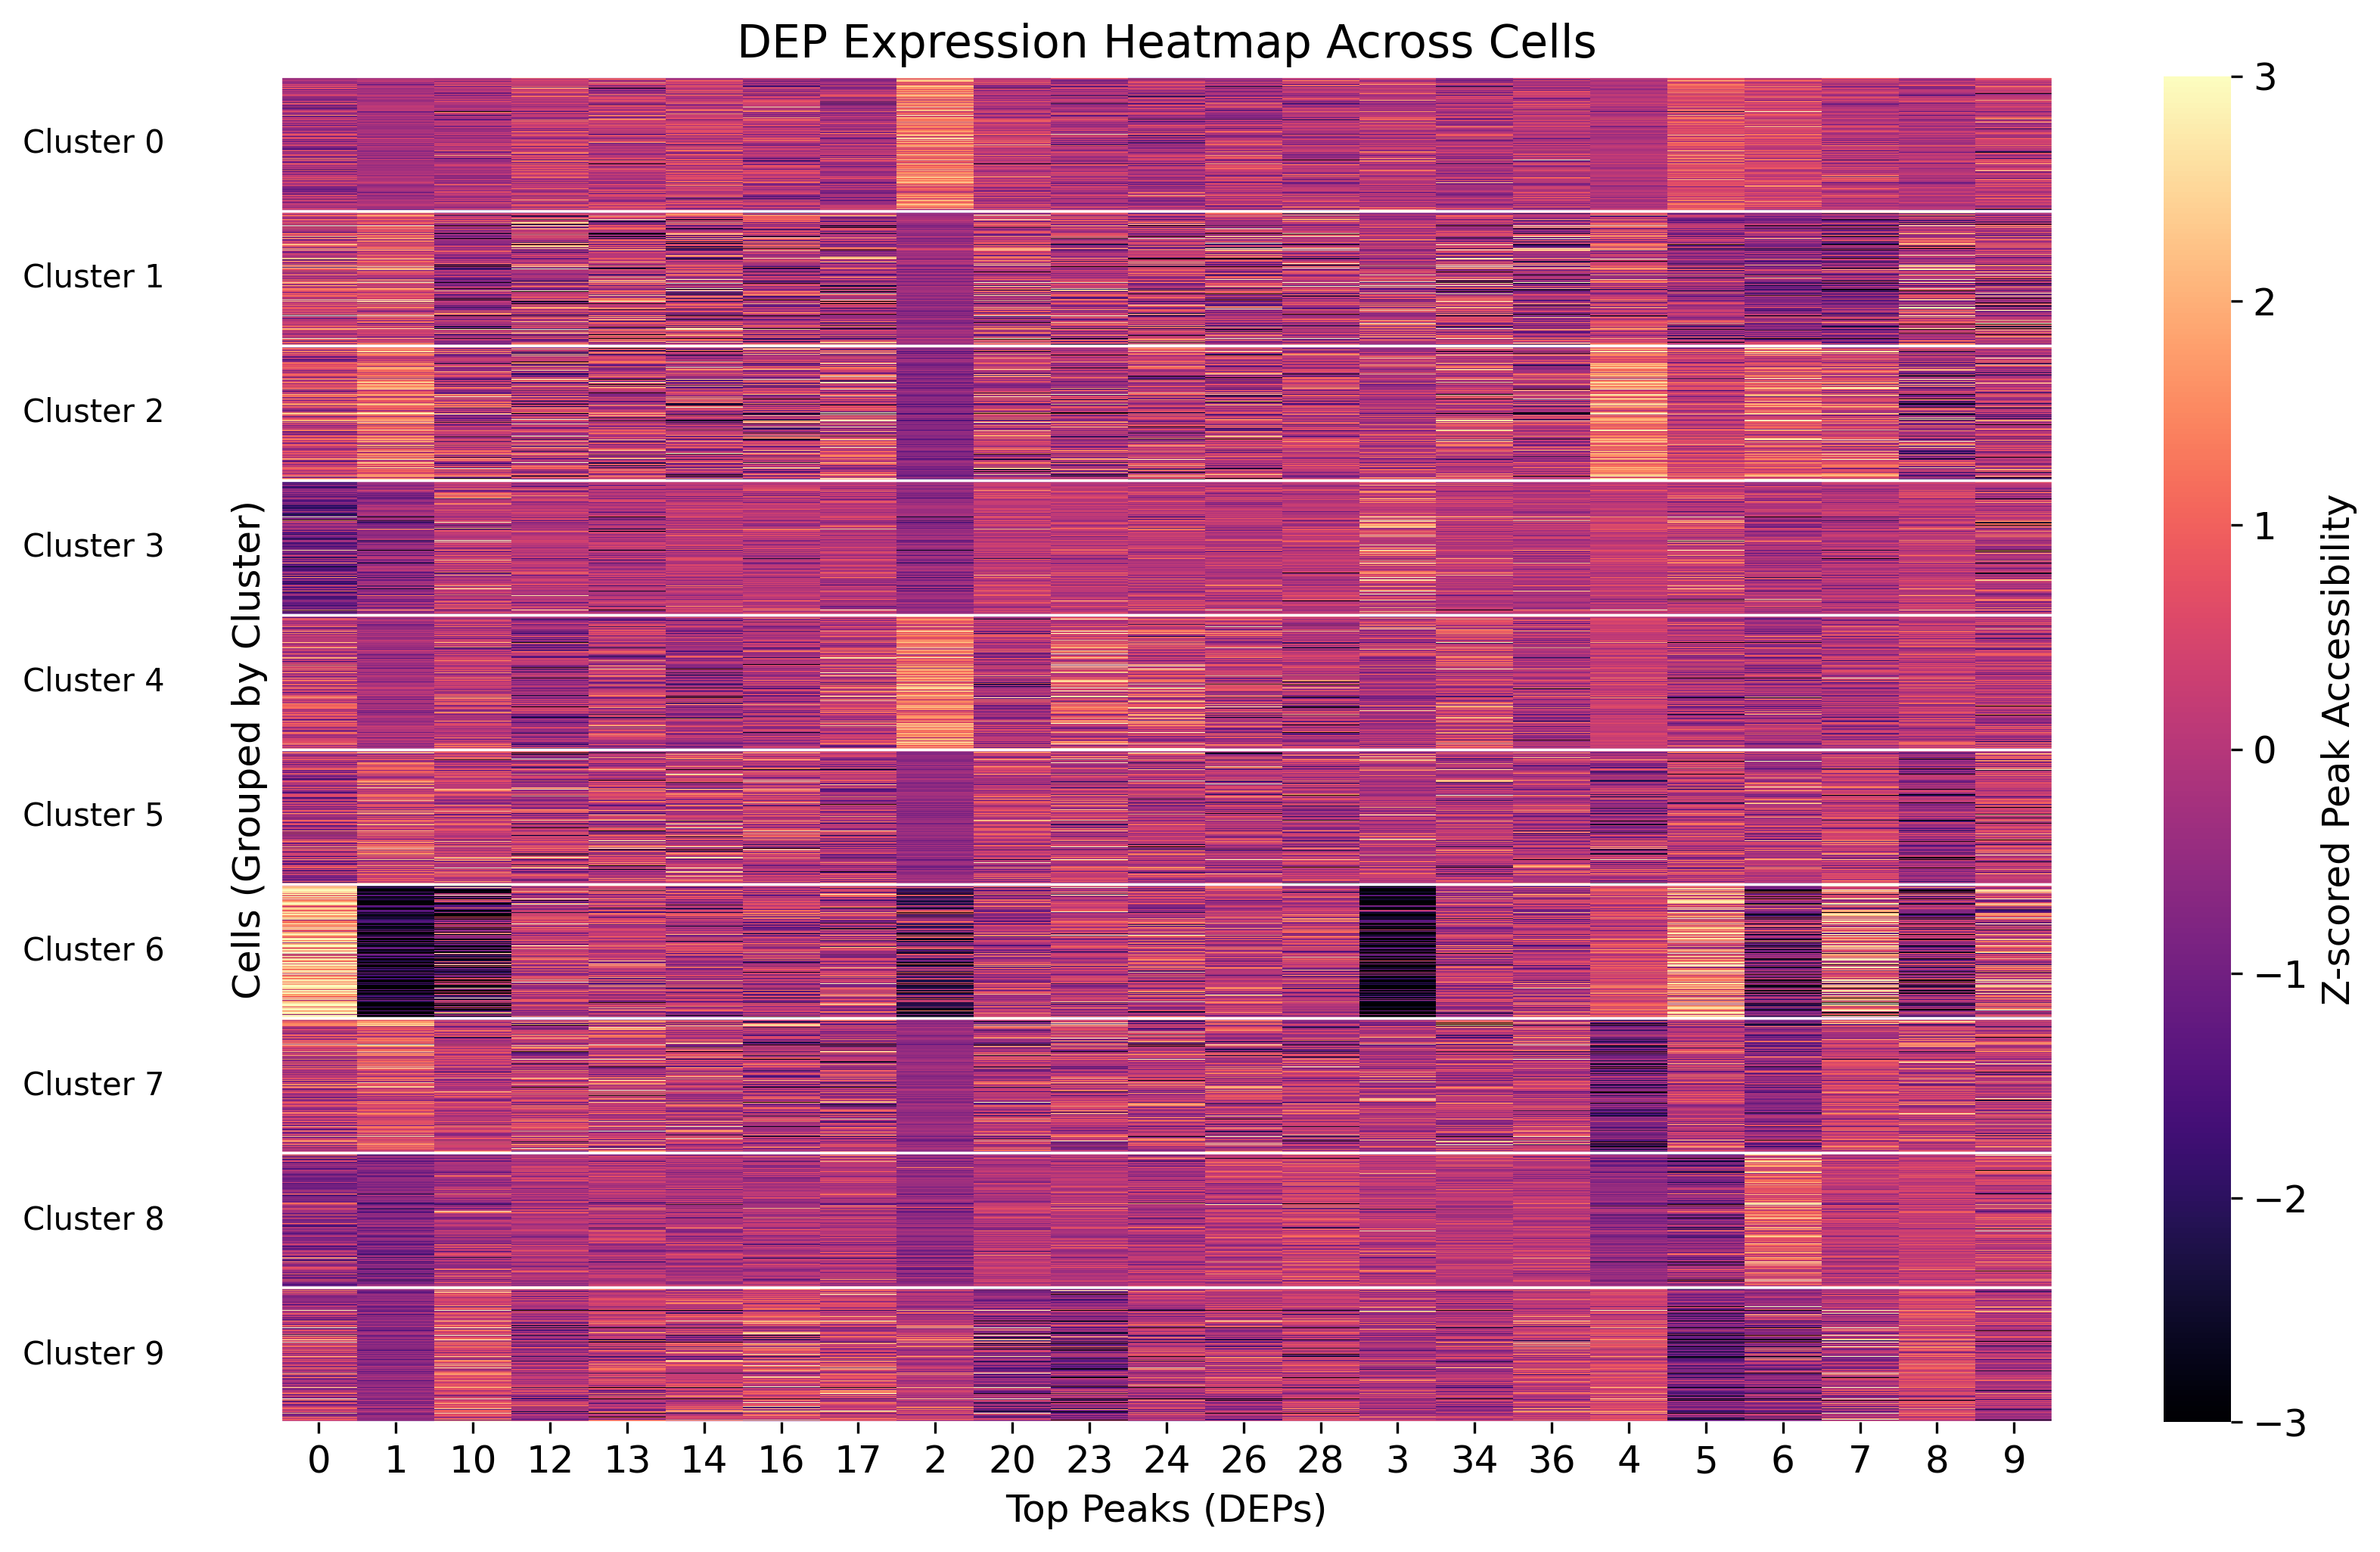

In [25]:
# heat map of cell-level DEPs
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle

adata2.obs['GSMO'] = adata_new.obs['GSMO']

sc.tl.rank_genes_groups(adata2, groupby='GSMO', method='t-test', n_genes=50)  

deg_results = adata2.uns['rank_genes_groups']
deg_df = pd.DataFrame(deg_results['names']).T
top_peaks = np.unique(deg_df.iloc[:, :5].values.flatten())  

adata_sub = adata2[:, top_peaks].copy()
sc.pp.scale(adata_sub, zero_center=True) 

expr = adata_sub.X.toarray() if not isinstance(adata_sub.X, np.ndarray) else adata_sub.X
expr = np.clip(expr, -3, 3)

expr_df = pd.DataFrame(expr, columns=top_peaks, index=adata_sub.obs_names)
expr_df['cluster'] = adata_sub.obs['GSMO'].values

n_cells_per_cluster = 600
clustered_dfs = []

for cluster in sorted(expr_df['cluster'].unique()):
    cluster_df = expr_df[expr_df['cluster'] == cluster].drop(columns='cluster')
    if len(cluster_df) >= n_cells_per_cluster:
        sampled = cluster_df.sample(n=n_cells_per_cluster, random_state=0)
    else:
        sampled = cluster_df.sample(n=n_cells_per_cluster, replace=True, random_state=0)
    sampled['cluster'] = cluster
    clustered_dfs.append(sampled)

uniform_df = pd.concat(clustered_dfs)
uniform_df_sorted = uniform_df.sort_values(by='cluster')
uniform_df_clean = uniform_df_sorted.drop(columns='cluster')

fig, ax = plt.subplots(figsize=(len(top_peaks) * 0.4 + 2, 7))
sns.heatmap(uniform_df_clean, cmap='magma', annot=False, yticklabels=False,
            cbar_kws={'label': 'Z-scored Peak Accessibility'}, linewidths=0, ax=ax)

cluster_labels = uniform_df_sorted['cluster'].values
cluster_start = 0
for cluster in sorted(np.unique(cluster_labels)):
    ax.add_patch(Rectangle((0, cluster_start), len(top_peaks), n_cells_per_cluster,
                           linewidth=0.8, edgecolor='white', facecolor='none'))
    y_center = cluster_start + n_cells_per_cluster / 2
    ax.text(-1.5, y_center, f'Cluster {cluster}', va='center', ha='right', fontsize=10)
    cluster_start += n_cells_per_cluster

plt.title("DEP Expression Heatmap Across Cells")
plt.xlabel("Top Peaks (DEPs)")
plt.ylabel("Cells (Grouped by Cluster)")
plt.tight_layout()

# plt.savefig("/opt/user2/1/gsmo/data/cosmos/DEP_cell_level_heatmap.png", dpi=600, bbox_inches='tight')
plt.show()


/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldc

<Figure size 3600x3000 with 0 Axes>

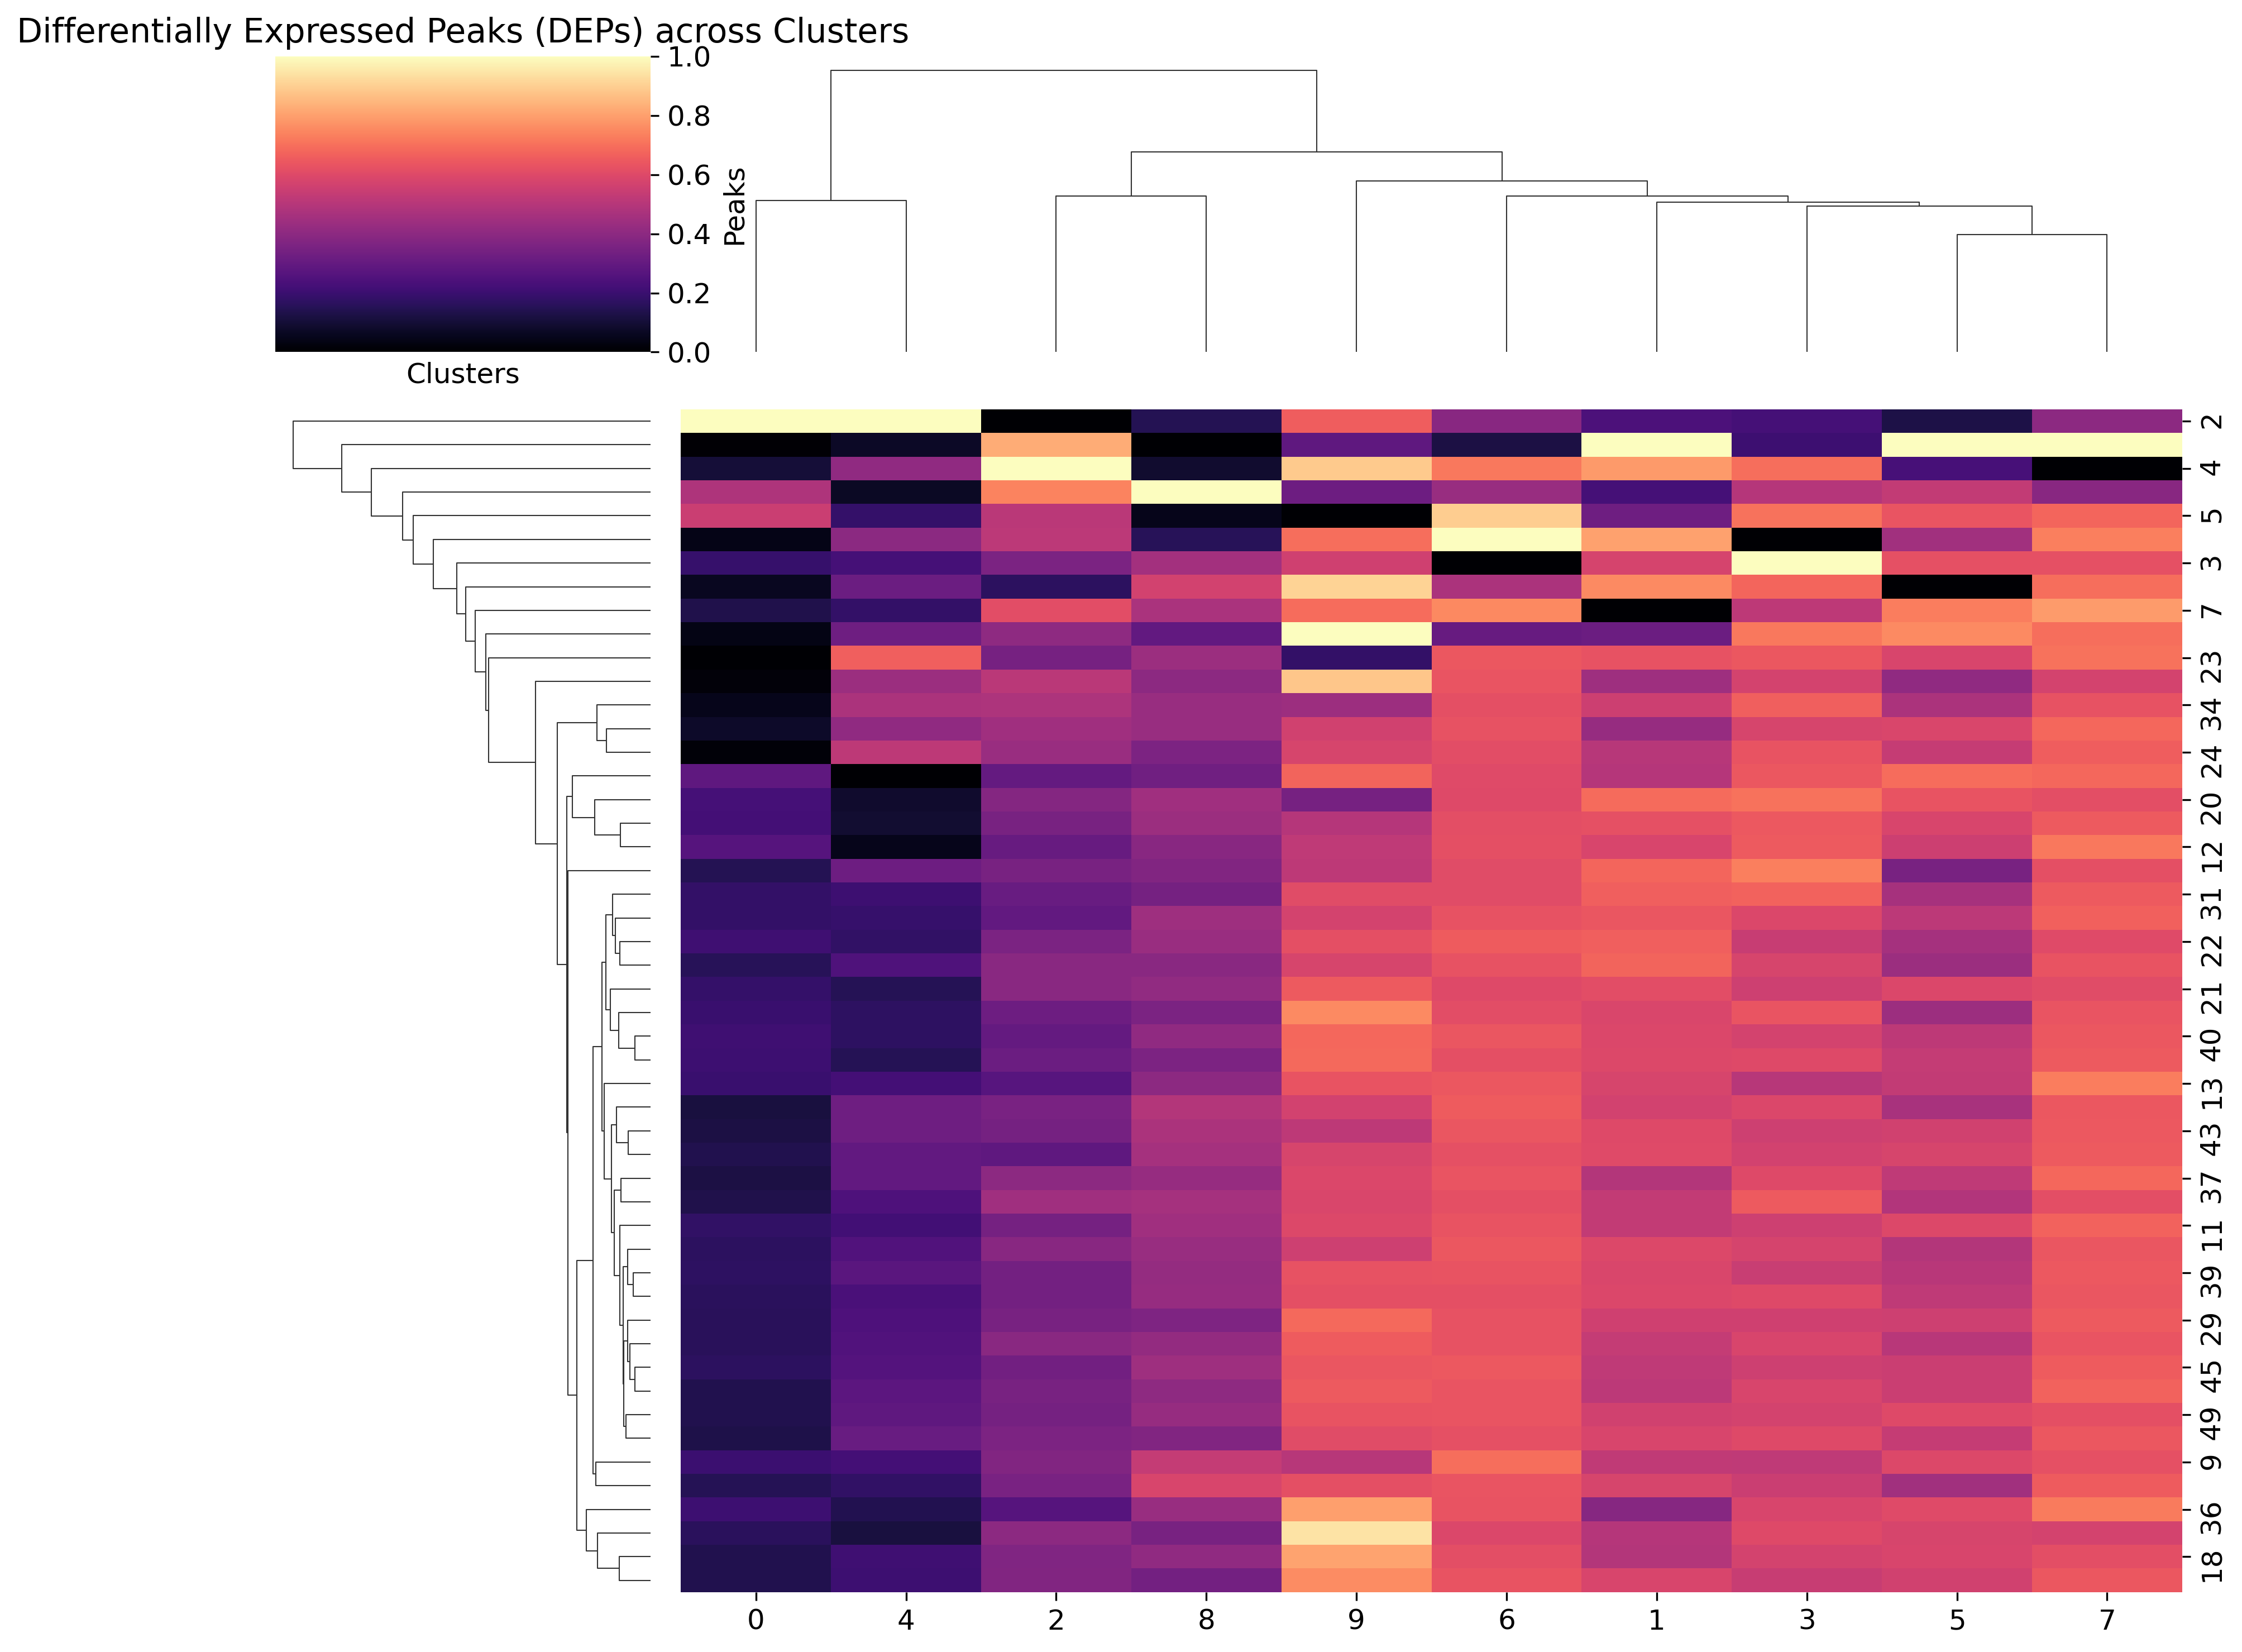

In [27]:
# Heat Map of DEPs across clusters

import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

adata2.obs['GSMO'] = adata_new.obs['GSMO']

sc.tl.rank_genes_groups(adata2, groupby='GSMO', method='t-test', n_genes=1000)  

deg_results = adata2.uns['rank_genes_groups']
deg_df = pd.DataFrame(deg_results['names']).T  

top_peaks = deg_df.iloc[0].values 

adata2.raw = adata2 
sc.pp.scale(adata2, zero_center=True)  

deg_peak_expression = []

for peak in top_peaks:
    peak_expression = []
    for cluster in np.unique(adata2.obs['GSMO']):
        cluster_cells = adata2[adata2.obs['GSMO'] == cluster]
        peak_expression.append(cluster_cells[:, peak].X.toarray().mean())
    deg_peak_expression.append(peak_expression)

deg_peak_expression = np.array(deg_peak_expression)
deg_peak_expression_df = pd.DataFrame(deg_peak_expression, columns=np.unique(adata2.obs['GSMO']), index=top_peaks)

peak_order = deg_peak_expression_df.mean(axis=1).sort_values(ascending=False).index
deg_peak_expression_df = deg_peak_expression_df.loc[peak_order, :]

cluster_order = deg_peak_expression_df.mean(axis=0).sort_values(ascending=False).index
deg_peak_expression_df = deg_peak_expression_df.loc[:, cluster_order]
cmap = 'magma'

plt.figure(figsize=(12, 10))  
sns.clustermap(deg_peak_expression_df, figsize=(12, 10), cmap=cmap, annot=False, standard_scale=1, cbar_kws={'label': 'Peak Expression'})

plt.title("Differentially Expressed Peaks (DEPs) across Clusters")
plt.xlabel("Clusters")
plt.ylabel("Peaks")
plt.tight_layout()
# plt.savefig("/opt/user2/1/gsmo/data/cosmos/DEP_heatmap_sorted.png", dpi=300, bbox_inches='tight')
plt.show()



/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 4500x3600 with 0 Axes>

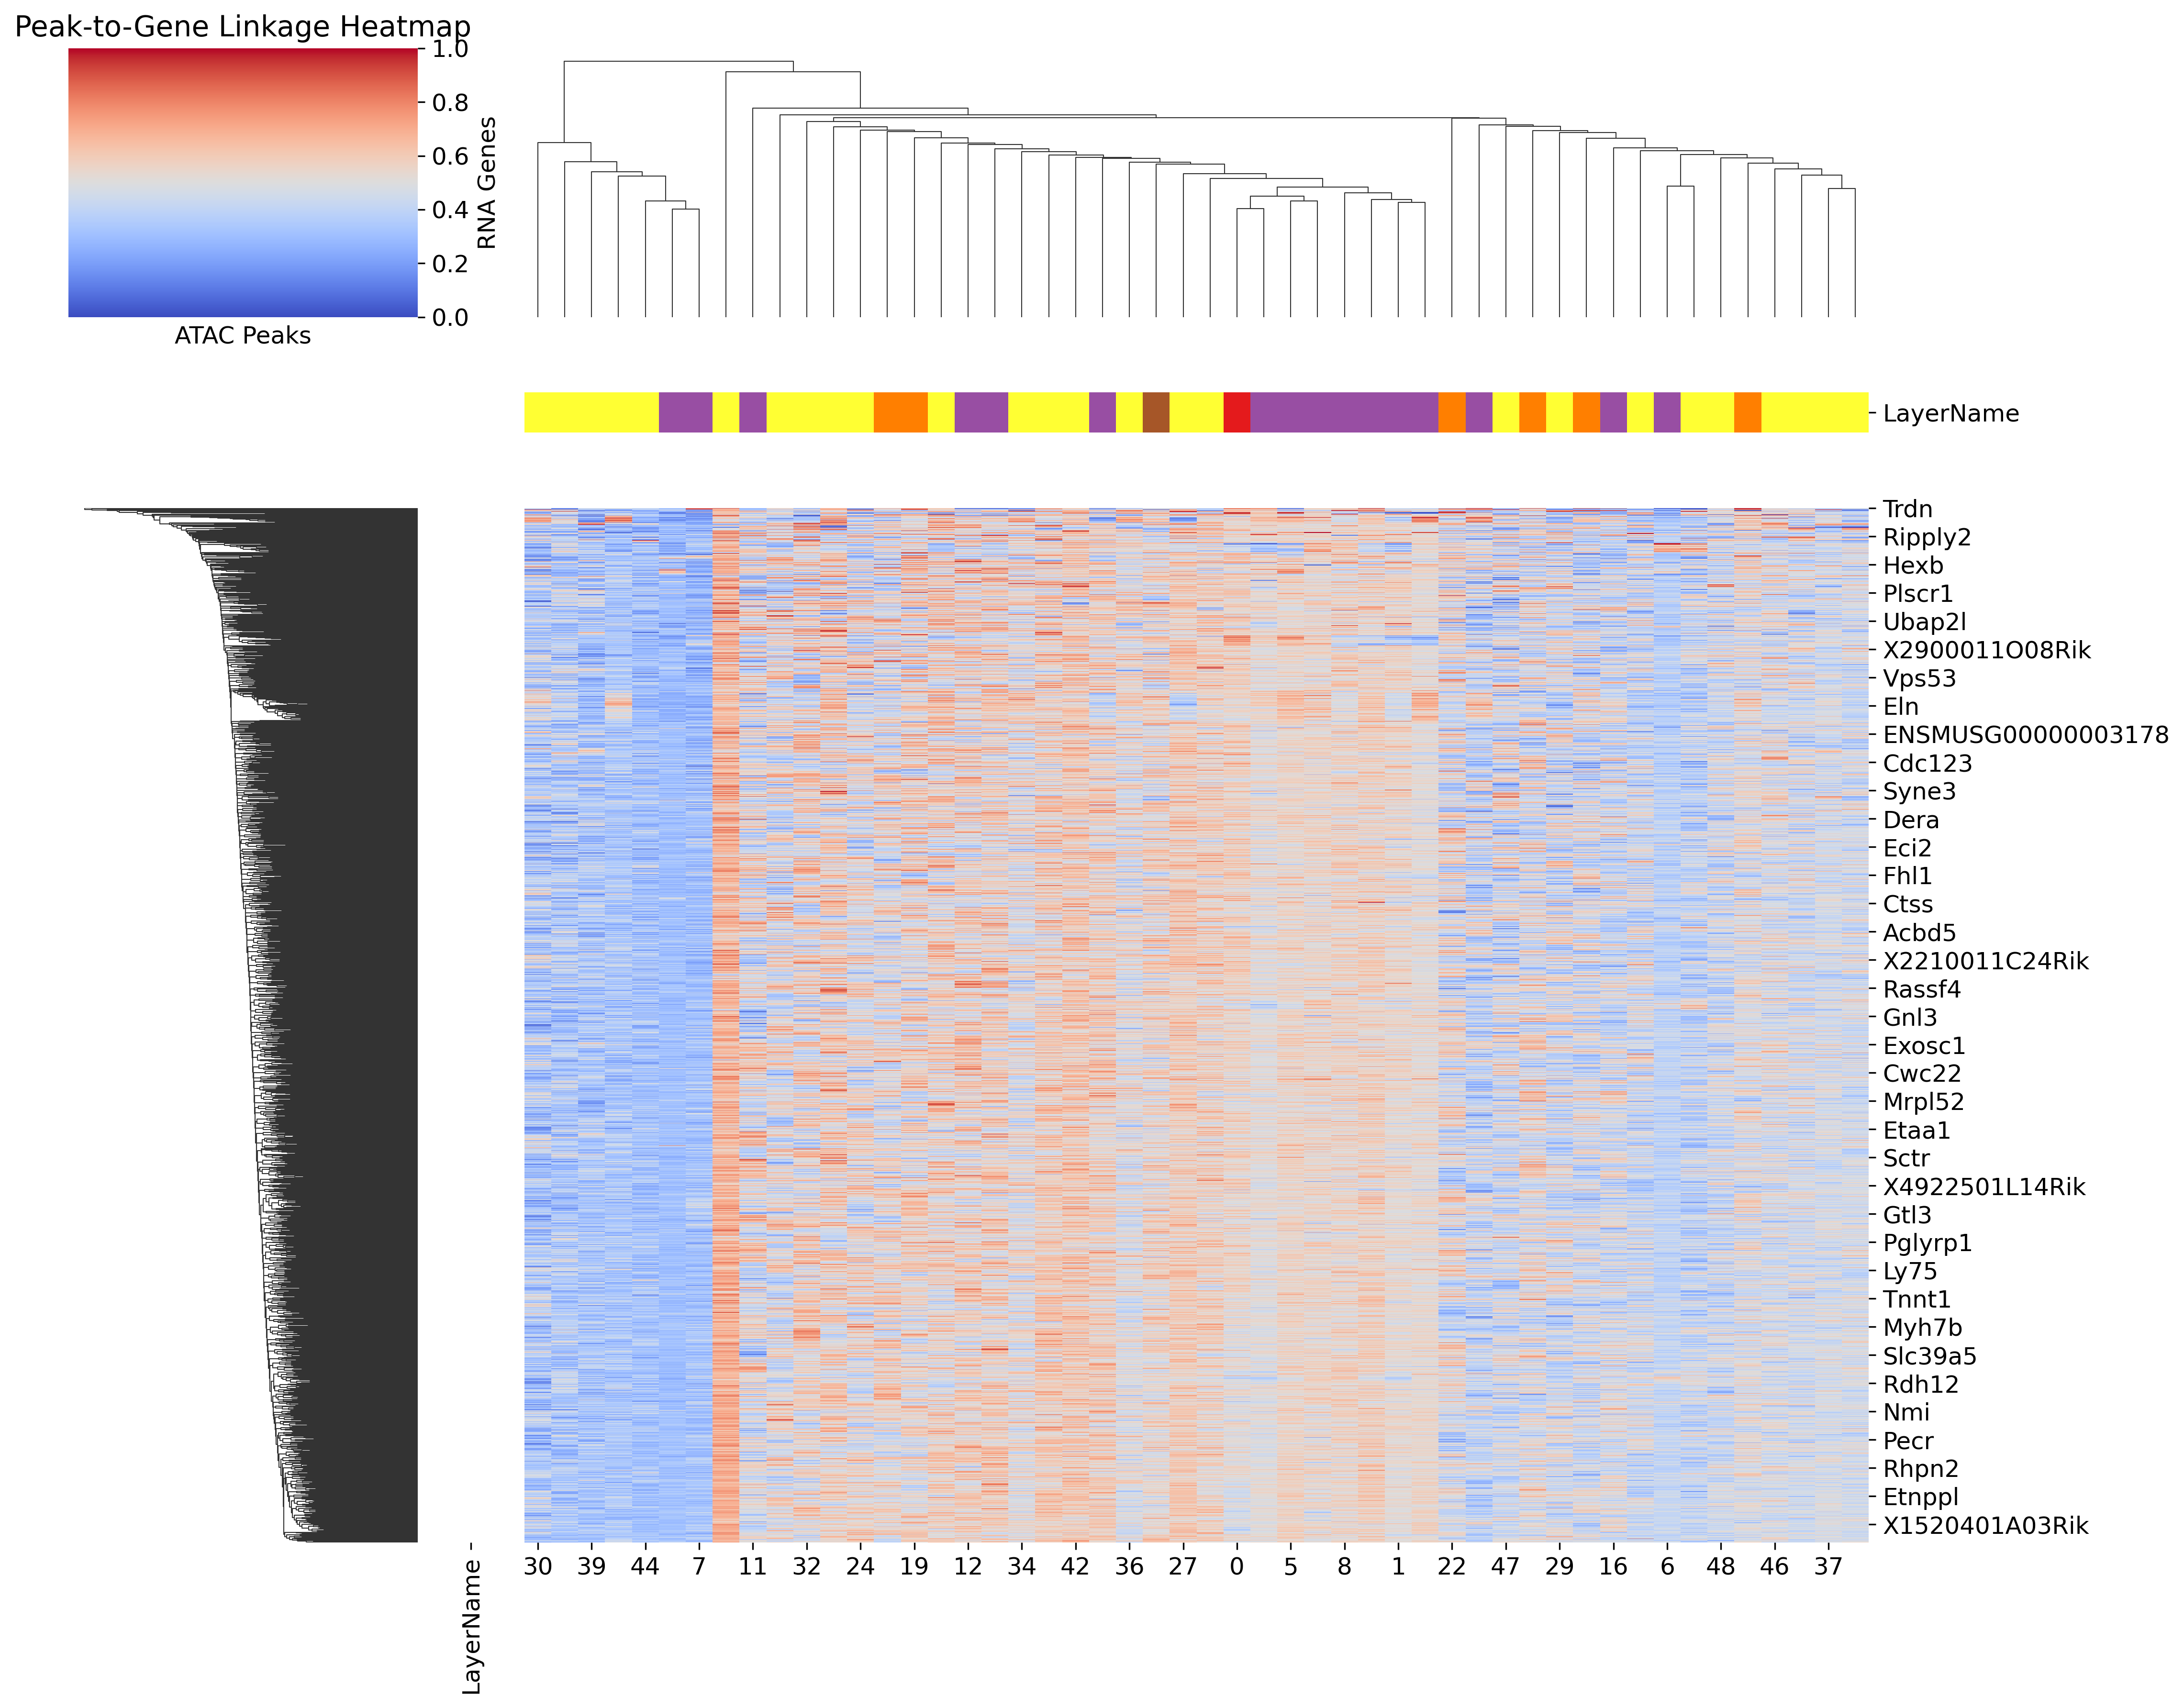

In [34]:
# RNA ATAC relation

import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


rna_data = adata1.X  

atac_data = adata2.X  

correlation_matrix = np.corrcoef(rna_data.T, atac_data.T)  
n_rna_genes = rna_data.shape[1]
n_atac_peaks = atac_data.shape[1]

gene_to_peak_corr = correlation_matrix[:n_rna_genes, n_rna_genes:]

correlation_df = pd.DataFrame(gene_to_peak_corr, 
                              index=adata1.var_names,  
                              columns=adata2.var_names)  

cmap = 'coolwarm'

cluster_labels = adata1.obs['LayerName']  

unique_labels = np.unique(cluster_labels)
colors = sns.color_palette("Set1", len(unique_labels))
cluster_colors = dict(zip(unique_labels, colors))

cluster_labels = adata1.obs['LayerName'].astype(object)  
cluster_annotation = cluster_labels.map(cluster_colors)

plt.figure(figsize=(15, 12)) 
'''sns.heatmap(correlation_df, cmap=cmap, annot=False, fmt='.2f', linewidths=0.5, 
            cbar_kws={'label': 'Pearson Correlation'}, square=True, 
            xticklabels=True, yticklabels=True, cbar=True)'''

sns.clustermap(correlation_df, figsize=(15, 12), cmap=cmap, annot=False, standard_scale=1, 
               row_cluster=True, col_cluster=True, 
               cbar_kws={'label': 'Pearson Correlation'}, 
               row_colors=cluster_annotation, col_colors=cluster_annotation)

plt.title("Peak-to-Gene Linkage Heatmap")
plt.xlabel("ATAC Peaks")
plt.ylabel("RNA Genes")
plt.tight_layout()

# plt.savefig("peak_to_gene_linkage_heatmap.png", dpi=300, bbox_inches='tight')

plt.show()